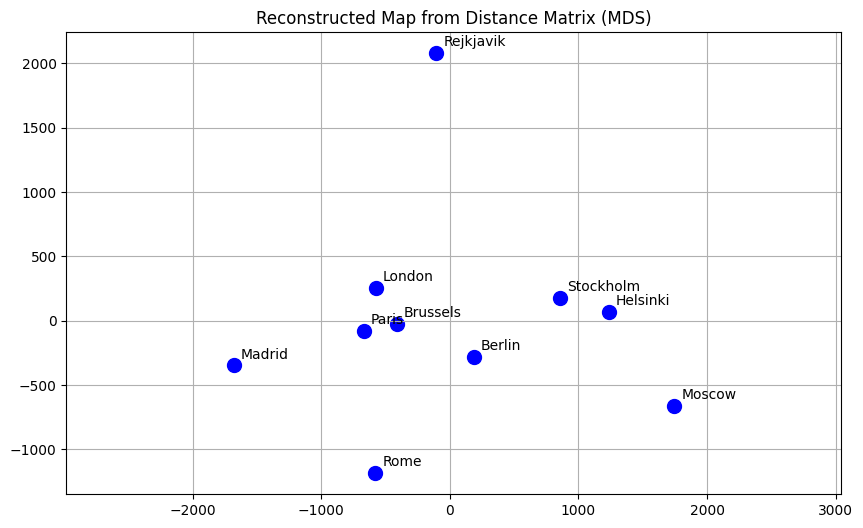

Reconstruction successful. Shape: (10, 2)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import euclidean_distances

def cmdscale(D_squared, k=2):
    """
    Classical Multidimensional Scaling (cMDS)
    Parameters:
    D_squared (n x n): Matrix of squared interpoint distances
    k (int): Target dimension
    
    Returns:
    Y (n x k): Projected coordinates
    """
    n = D_squared.shape[0]
    
    # 1. Compute Centering Matrix H
    H = np.eye(n) - (1/n) * np.ones((n, n))
    
    # 2. Compute B = -1/2 * H * D_squared * H
    B = -0.5 * H @ D_squared @ H
    
    # 3. Spectral Decomposition
    # np.linalg.eigh returns eigenvalues in ASCENDING order
    evals, evecs = np.linalg.eigh(B)
    
    # Sort DESCENDING (Flip arrays)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    # 4. Zero out negative eigenvalues (for non-Euclidean noise)
    # This matches Step 3 of your lecture notes
    evals_pos = np.maximum(evals, 0)
    
    # 5. Compute Coordinates Y
    # Diagonal matrix of sqrt(eigenvalues)
    Lambda_sqrt = np.diag(np.sqrt(evals_pos))
    
    # Project: Y = U * Lambda^1/2
    Y = evecs @ Lambda_sqrt
    
    # 6. Return first k columns
    return Y[:, :k]

# --- Data Loading / Simulation ---
# If you don't have cities.txt, we use this dummy data
# 1. Read the whole file as a single list of words/numbers
# .split() automatically ignores newlines and spaces!
raw_data = open('cities.txt').read().split()

# 2. Extract names (Indices might need adjustment based on where "# Cities:" falls)
# Assuming the file starts with "# Cities: City1 City2..."
# The first distinct city name is usually at index 2 or 3 depending on the hash.
city_names = raw_data[2:12] 

# 3. Extract the numbers and reshape
# Everything after the names is the matrix
matrix_values = [float(x) for x in raw_data[12:]]
D = np.array(matrix_values).reshape(10, 10)
D_squared = D ** 2

# --- Run MDS ---
# Project 2D coordinates
Y_k = cmdscale(D_squared, k=2)

# --- Rotation (Optional) ---
# MDS output has arbitrary rotation. We can rotate it manually to look like a map.
def rotate(points, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T

# Try changing this angle if the map looks upside down!
Y_rotated = rotate(Y_k, angle_degrees=180) 

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.scatter(Y_rotated[:, 0], Y_rotated[:, 1], c='blue', s=100)

# FIX: Use 'city_names' instead of 'names'
for i, name in enumerate(city_names): 
    plt.annotate(name, (Y_rotated[i, 0], Y_rotated[i, 1]), 
                 xytext=(5, 5), textcoords='offset points')

plt.title("Reconstructed Map from Distance Matrix (MDS)")
plt.grid(True)
plt.axis('equal') 
plt.show()

# Verification
print("Reconstruction successful. Shape:", Y_k.shape)

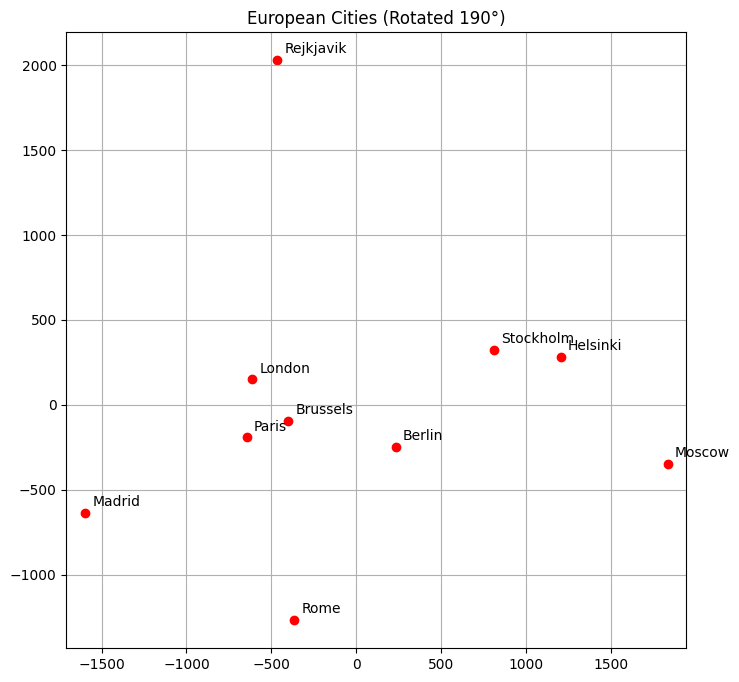

In [ ]:
# --- 2. MDS Function ---
def cmdscale(D, k=2):
    """
    Classical MDS: Projects n points into k-dimensional space.
    """
    n = D.shape[0]
    H = np.eye(n) - (1/n) * np.ones((n, n))
    B = -0.5 * H @ D @ H
    
    evals, evecs = np.linalg.eigh(B)
    
    # Sort descending
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    # Project
    w_pos = np.maximum(evals, 0)
    Y = evecs @ np.diag(np.sqrt(w_pos))
    return Y[:, :k]

# --- 3. Rotation Function (The Homework Requirement) ---
def rotate_data(X, angle_degrees):
    """
    Rotates 2D data X by angle_degrees (counter-clockwise).
    """
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    
    # Rotation Matrix
    R = np.array([[c, -s], 
                  [s,  c]])
    
    # Apply R to every point. 
    # Since X is (N x 2), we compute (R @ X.T).T or simply X @ R.T
    return X @ R.T

# --- 4. Plotting Function ---
def plot_map(X, labels, title="MDS Map"):
    plt.figure(figsize=(8, 8))
    plt.scatter(X[:, 0], X[:, 1], c='red', marker='o')
    
    for i, txt in enumerate(labels):
        plt.annotate(txt, (X[i, 0], X[i, 1]), 
                     xytext=(5, 5), textcoords='offset points')
        
    plt.title(title)
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# --- Execution ---
# 1. Get raw MDS coordinates
Y_raw = cmdscale(D_squared)

# 2. Rotate
# Trial and Error: 190 degrees usually flips it "North-Up" for this specific data
best_angle = 190 
Y_rotated = rotate_data(Y_raw, best_angle)

# OPTIONAL: Reflection
# If the map is mirrored (e.g. London is East of Berlin), uncomment this:
# Y_rotated[:, 0] = -Y_rotated[:, 0] 

# 3. Plot
plot_map(Y_rotated, city_names, title=f"European Cities (Rotated {best_angle} degrees)")